In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_rows', None) # tum stunlari göstermek icin

In [3]:
df = pd.read_csv("Machine_Learning_Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Yeni oluşan eksik veri sayısı: 11


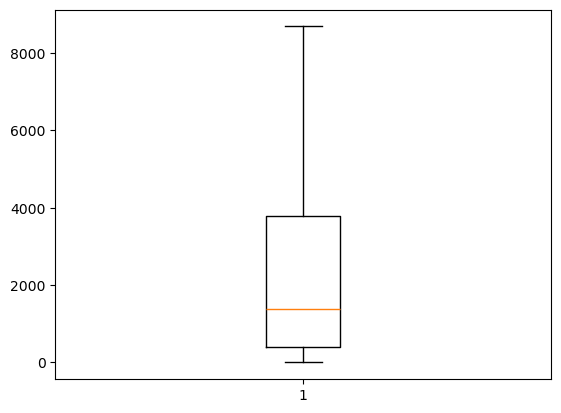

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# 'coerce' parametresi hatalı karakterleri (boşlukları) NaN yapar
print(f"Yeni oluşan eksik veri sayısı: {df['TotalCharges'].isnull().sum()}")
# Boş değerleri 0 ile dolduruyoruz
df['TotalCharges'] = df['TotalCharges'].fillna(0)

plt.boxplot(df["TotalCharges"])
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
df_categorical = df[["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity",
                    "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling",
                    "PaymentMethod","Churn"]]
for col in df_categorical:
    print(df_categorical[col].value_counts())
    print("----------------------------------")
    

gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
----------------------------------
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
----------------------------------
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
----------------------------------
DeviceProt

In [14]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [16]:
one_hot_cols = ["MultipleLines","InternetService","OnlineSecurity",
                    "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
                    "PaymentMethod"]

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True,)# dtype=int -> tip belirtmek icin yazabilirsin


In [17]:
# Sözleşme tipleri için mantıksal bir harita oluşturuyoruz
contract_mapping = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

# map() fonksiyonu ile her değeri rakamla değiştiriyoruz
df['Contract'] = df['Contract'].map(contract_mapping)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   Contract                               7043 non-null   int64  
 8   PaperlessBilling                       7043 non-null   int64  
 9   MonthlyCharges                         7043 non-null   float64
 10  TotalCharges                           7043 non-null   float64
 11  Chur

In [19]:
df.isnull().sum()

customerID                               0
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
Contract                                 0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport

In [20]:
df = df.drop("customerID", axis=1)

In [21]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [23]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,0,0,0,1,21,1,1,0,64.85,1336.80,...,True,False,False,False,False,False,True,False,False,True
1623,0,0,0,0,54,1,2,1,97.20,5129.45,...,False,False,False,False,True,False,True,False,False,False
6074,1,0,1,0,1,0,0,1,23.45,23.45,...,False,False,False,False,False,False,False,False,True,False
1362,1,0,0,0,4,1,0,1,70.20,237.95,...,False,False,False,False,False,False,False,False,True,False
6754,1,0,0,1,0,1,2,1,61.90,0.00,...,False,False,True,False,False,False,False,False,False,False


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# sadece surekli degeri olan stunlari ölceklendiriyoruz. 1 ve 0 olan , encoding yaptigimiz stunlari ölceklendirmeye gerek yok
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Sadece bu sütunları fit_transform yapıyoruz
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Test setine ise sadece transform uyguluyoruz (Eğitim setinden öğrendiği bilgilerle)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [26]:
models = {
    "Random Forest Classifier" : RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "KNeighbors Classifier" : KNeighborsClassifier(),
    "Decision Tree Classifier"  : DecisionTreeClassifier(),
    "SVC" : SVC(),
    "LightGBM" : LGBMClassifier(),
    "XGBoost" : XGBClassifier(),
    "AdaBoost Classifier" : AdaBoostClassifier()
}

In [28]:
def calculate_model_metrics(true, predicted):
    accuracy = accuracy_score(true, predicted)
    classification = classification_report(true, predicted)
    con_matrix = confusion_matrix(true, predicted)
    return accuracy, classification, con_matrix

In [30]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train) 
    y_test_pred = model.predict(X_test) 
    
    model_train_accuracy, model_train_classification, model_train_con_matrix = calculate_model_metrics(y_train, y_train_pred)
    model_test_accuracy, model_test_classification, model_test_con_matrix = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("Accuracy Train : ", model_train_accuracy)
    print("Classification Report : \n", model_train_classification)
    print("Confusion Matrix : \n", model_train_con_matrix)

    print("-----------------------------")
    
    print("Evaluation for Test Set")
    print("Accuracy Test : ", model_test_accuracy)
    print("Classification Report : \n", model_test_classification)
    print("Confusion Matrix : \n", model_test_con_matrix)

    print("-----------------------------")
    print("\n")

RandomForestClassifier()
Evaluation for Training Set
Accuracy Train :  0.9985800496982605
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4138
           1       1.00      1.00      1.00      1496

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634

Confusion Matrix : 
 [[4134    4]
 [   4 1492]]
-----------------------------
Evaluation for Test Set
Accuracy Test :  0.7913413768630234
Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.64      0.48      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix : 
 [[937  99]
 [195 178]]
----------------------

In [31]:
from lazypredict.Supervised import LazyClassifier

In [32]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000506 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


In [33]:
print(models)

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
QuadraticDiscriminantAnalysis      0.77               0.77     0.77      0.78   
GaussianNB                         0.76               0.76     0.76      0.77   
NearestCentroid                    0.71               0.76     0.76      0.73   
Perceptron                         0.75               0.75     0.75      0.76   
SGDClassifier                      0.79               0.74     0.74      0.79   
BernoulliNB                        0.78               0.74     0.74      0.79   
LogisticRegression                 0.81               0.73     0.73      0.80   
CalibratedClassifierCV             0.81               0.72     0.72      0.80   
LinearDiscriminantAnalysis         0.80               0.72     0.72      0.80   
AdaBoostClassifier                 0.80               0.72     0.72      0.80   
LinearSVC                   